# 📊 Credit Risk Classification (ML Project)

## 🎯 Objective
Build a machine learning model to classify whether a customer represents a high credit risk.

## 🧠 Approach
- Generate synthetic financial data
- Perform feature engineering
- Train a Logistic Regression model
- Evaluate performance using classification metrics and ROC-AUC
- Interpret model coefficients


In [2]:
!pip install pandas==2.2.3
!pip install scikit-learn==1.6.0
!pip install matplotlib==3.9.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 159.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 121.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 140.9 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 78.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 105.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 82.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 139.2 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

## 📌 Generate Dataset

In [4]:
np.random.seed(42)
n = 2000

df = pd.DataFrame({
    "age": np.random.randint(21, 65, n),
    "income": np.random.randint(15000, 120000, n),
    "loan_amount": np.random.randint(1000, 60000, n),
    "credit_score": np.random.randint(300, 850, n),
    "years_employed": np.random.randint(0, 25, n)
})

## 📌 Feature Engineering

In [5]:
df["debt_to_income"] = df["loan_amount"] / df["income"]

## 📌 Create Target Variable

In [6]:
df["risk"] = (
    (df["credit_score"] < 580) |
    (df["debt_to_income"] > 0.5) |
    (df["years_employed"] < 2)
).astype(int)

## 📌 Train-Test Split

In [7]:
X = df.drop("risk", axis=1)
y = df["risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 📌 Scaling

In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 📌 Train Model

In [9]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

## 📌 Predictions

In [10]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

## 📌 Evaluation

In [11]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_auc)

Confusion Matrix:
[[ 86  18]
 [ 23 273]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.83      0.81       104
           1       0.94      0.92      0.93       296

    accuracy                           0.90       400
   macro avg       0.86      0.87      0.87       400
weighted avg       0.90      0.90      0.90       400

ROC-AUC Score: 0.9597193347193347


## 📊 ROC Curve

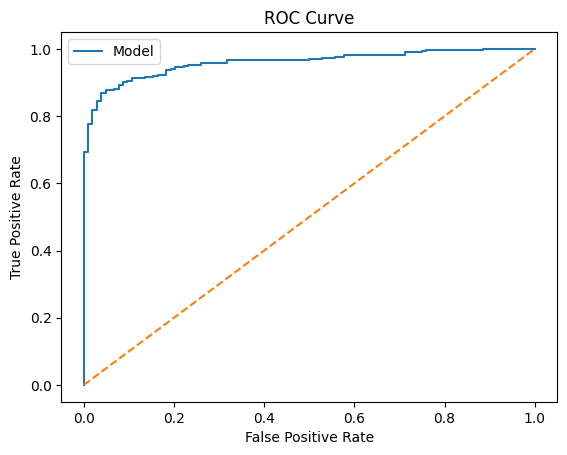

In [12]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label="Model")
plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

## 📌 Feature Importance

In [13]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

feature_importance.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
5,debt_to_income,5.087951
0,age,-0.075454
1,income,-0.159430
2,loan_amount,-0.288091
4,years_employed,-0.330242
3,credit_score,-2.649412
